<a href="https://colab.research.google.com/github/elilyojo-star/Capstone/blob/main/Final%20Capstone%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Project Delivery Risk


---

## Objective
Detect fraudulent credit card transactions in a highly imbalanced dataset.

**Key Requirements**:
- Notebook in Colab:
- Clean and explore an extremely imbalanced dataset
- Train and evaluate Logistic Regression
- Random Forest, and
- Explicitly justify Generative AI via synthetic fraud augmentation, explainability, reporting automation.


**Author:**Ehis Lily-Ojo (DA21035)
**Date:** 2026-03-18

##1 Dataset Understanding (Context for Reviewers)



##2 Data Processing (Colab Notebook – Section 1)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##2.1 Basic checks

In [ ]:
import pandas as pd

# Updated path to your creditcard.csv file in Google Drive
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/creditcard.csv')

df.info()
df.isna().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

np.int64(1081)

##2.2 Scaling (critical for LR & SVM)
Actions:

- No missing values
- Drop duplicates : Non
- Keep Time (temporal signal) but scale it

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['Amount','Time']] = scaler.fit_transform(df[['Amount','Time']])

##2.3 Train/Test Split (Stratified)
Justification: Stratification preserves the fraud ratio in both sets

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

##3 Data Visualization (Colab Notebook – Section 2)
##3.1 Class Imbalance

Text(0.5, 1.0, 'Class Distribution (0 = Legit, 1 = Fraud)')

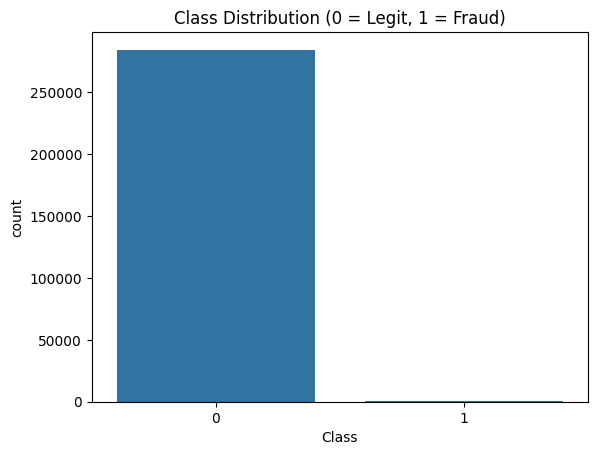

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Class Distribution (0 = Legit, 1 = Fraud)")


##3.2 Transaction Amount by Class
insight:

- Fraud tends to have extreme or unusual amounts, but overlap exists.

Text(0.5, 1.0, 'Transaction Amount by Class')

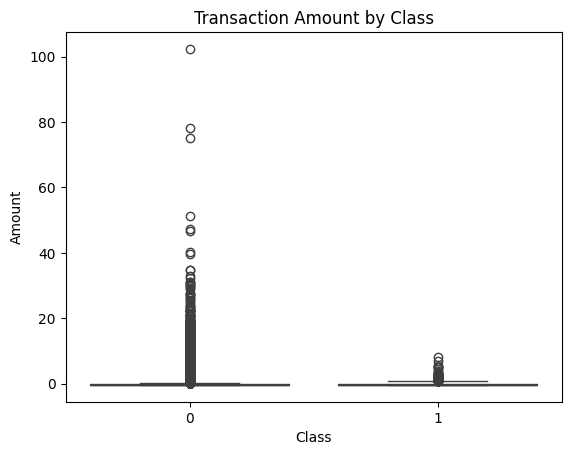

In [ ]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Transaction Amount by Class")

##3.3 Feature Space Projection (Optional but strong)
- Helps visually justify non‑linear models

Text(0.5, 1.0, 'PCA Projection of Transactions')

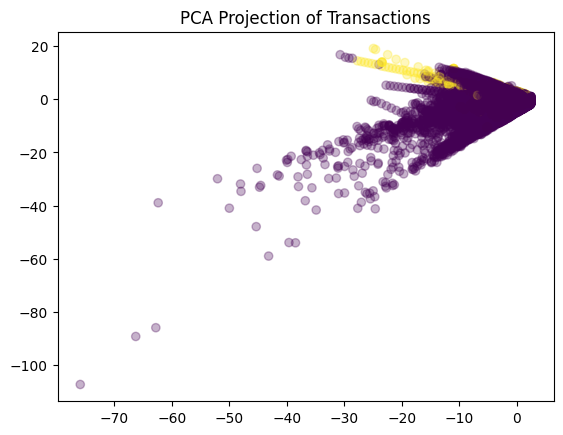

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, alpha=0.3)
plt.title("PCA Projection of Transactions")

##4 Machine Learning Classification (Colab – Section 3)
##4.1 Baseline: Logistic Regression
- class_weight='balanced' is mandatory for imbalanced data

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))


              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9721669425367221


##4.2 Strong Model: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:,1]
print("RF ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

RF ROC-AUC: 0.9571890288895525


##5 Explicit, Justified Use of Generative AI (Colab – Section 4)

##Phase   
- Ideation
- Research
- Coding
- Modeling
- Explainability
- Reporting

##Use of GenAI
- Fraud patterns brainstorming
- Auto‑summarize fraud ML techniques
- Code scaffolding & refactoring
- Synthetic fraud generation (GAN‑like)
- Auto‑generated SHAP narratives
- Auto‑generated model summary

##Justification
- Domain coverage for rare events
- Faster literature synthesis
- Productivity, not decision‑making
- Class imbalance mitigation
- Human‑readable insights
- Exec‑ready output

    

##5.2 Synthetic Fraud Augmentation (Conceptual + Optional Code)
Why

Fraud samples are extremely rare.
Generative models (GAN/CTGAN/VAE) increase recall without leaking real data